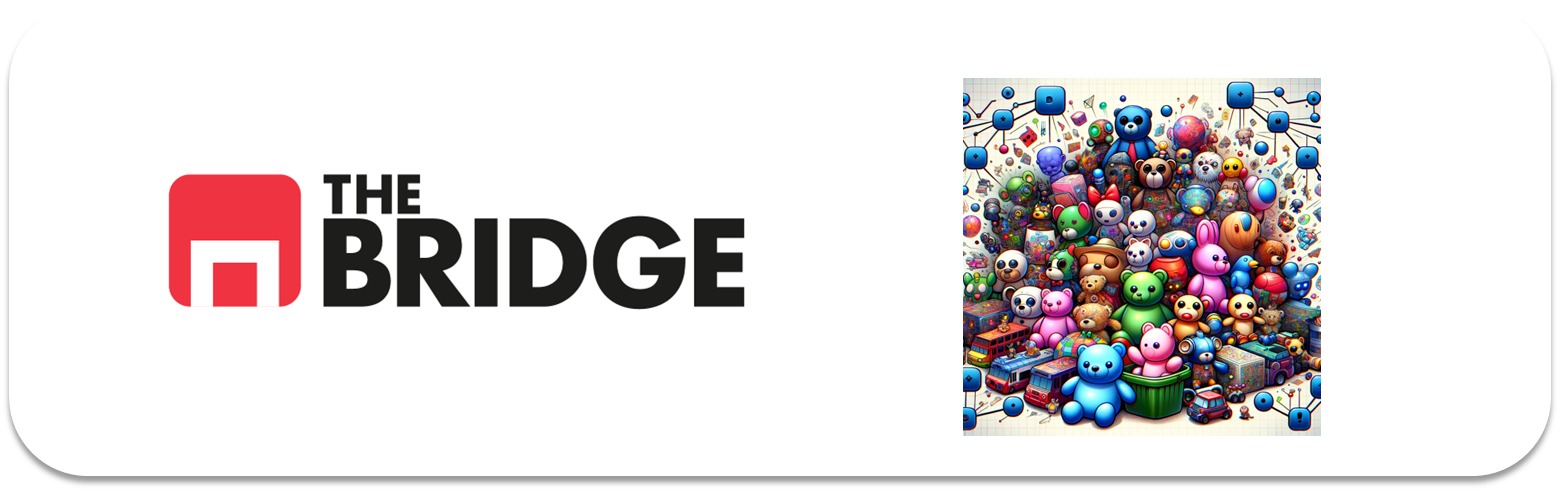

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [2]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti['DESCR'])

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\sandy\scikit_learn_data
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for s

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [3]:
print(olivetti.target)
print(f"Shape del target: {olivetti.target.shape}")
print(f"Valores únicos (personas): {np.unique(olivetti.target)}")
print(f"Número de personas distintas: {len(np.unique(olivetti.target))}")

[ 0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  2  2  2  2
  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  4  4  4  4  4  4  4  4
  4  4  5  5  5  5  5  5  5  5  5  5  6  6  6  6  6  6  6  6  6  6  7  7
  7  7  7  7  7  7  7  7  8  8  8  8  8  8  8  8  8  8  9  9  9  9  9  9
  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11
 12 12 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14
 14 14 14 14 14 14 15 15 15 15 15 15 15 15 15 15 16 16 16 16 16 16 16 16
 16 16 17 17 17 17 17 17 17 17 17 17 18 18 18 18 18 18 18 18 18 18 19 19
 19 19 19 19 19 19 19 19 20 20 20 20 20 20 20 20 20 20 21 21 21 21 21 21
 21 21 21 21 22 22 22 22 22 22 22 22 22 22 23 23 23 23 23 23 23 23 23 23
 24 24 24 24 24 24 24 24 24 24 25 25 25 25 25 25 25 25 25 25 26 26 26 26
 26 26 26 26 26 26 27 27 27 27 27 27 27 27 27 27 28 28 28 28 28 28 28 28
 28 28 29 29 29 29 29 29 29 29 29 29 30 30 30 30 30 30 30 30 30 30 31 31
 31 31 31 31 31 31 31 31 32 32 32 32 32 32 32 32 32

In [4]:
df_faces = pd.DataFrame(olivetti.data)

In [5]:
df_faces['target'] = olivetti.target

print(df_faces.shape)
df_faces.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [6]:
df_faces_shuffled = df_faces.sample(frac=1, random_state=42).reset_index(drop=True)

df_faces_shuffled.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.198347,0.235537,0.351240,0.409091,0.421488,0.429752,0.500000,0.528926,0.524793,0.553719,...,0.508264,0.524793,0.504132,0.483471,0.471074,0.285124,0.061983,0.128099,0.090909,20
1,0.185950,0.128099,0.115702,0.132231,0.185950,0.268595,0.433884,0.541322,0.570248,0.586777,...,0.396694,0.409091,0.301653,0.421488,0.462810,0.247934,0.190083,0.210744,0.210744,28
2,0.508264,0.603306,0.619835,0.628099,0.657025,0.665289,0.690083,0.727273,0.743802,0.768595,...,0.301653,0.305785,0.314050,0.326446,0.338843,0.330579,0.334711,0.342975,0.342975,3
3,0.136364,0.140496,0.185950,0.280992,0.318182,0.363636,0.409091,0.417355,0.438017,0.454545,...,0.169421,0.206612,0.276859,0.355372,0.685950,0.661157,0.280992,0.371901,0.276859,21
4,0.652893,0.644628,0.652893,0.706612,0.714876,0.719008,0.743802,0.747934,0.747934,0.756198,...,0.074380,0.074380,0.082645,0.082645,0.111570,0.070248,0.086777,0.185950,0.231405,9


### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [7]:
from sklearn.model_selection import train_test_split

X = df_faces_shuffled.drop(columns=['target'])
y = df_faces_shuffled['target']

# Primer split: separamos el 10% para test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# Segundo split: del 90% restante, separamos otro 10% del TOTAL para validación
# 10% del total equivale aproximadamente a 0.10 / 0.90 ≈ 0.1111 del conjunto restante
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} imágenes ({X_train.shape[0]/len(df_faces_shuffled)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} imágenes ({X_val.shape[0]/len(df_faces_shuffled)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} imágenes ({X_test.shape[0]/len(df_faces_shuffled)*100:.1f}%)")

Train: 320 imágenes (80.0%)
Validation: 40 imágenes (10.0%)
Test: 40 imágenes (10.0%)


### #1.4

Crea los pares X,y para train, validation y test.

In [8]:
# Pares X, y para cada conjunto (ya generados en el split anterior)

# Train
X_train, y_train

# Validation
X_val, y_val

# Test
X_test, y_test

# Comprobación rápida de shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (320, 4096) (320,)
Validation: (40, 4096) (40,)
Test: (40, 4096) (40,)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [9]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

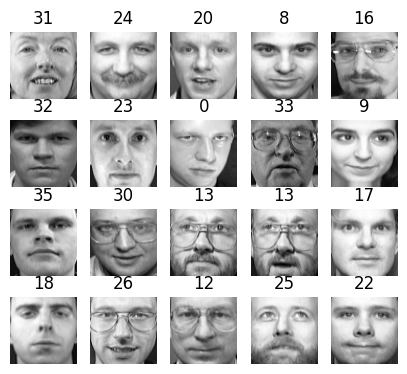

In [11]:
# Convertir a numpy array (la función espera faces.reshape, que es método de numpy)
faces_train = X_train.values  # o X_train.to_numpy()
labels_train = y_train.values

# Mostrar las primeras 20 caras de train, por ejemplo
plot_faces(faces_train[:20], labels_train[:20])

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [12]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(221)

### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

In [13]:
k_values = range(5, 151, 5)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette_score={score:.4f}")


k=5: silhouette_score=0.1088
k=10: silhouette_score=0.1040
k=15: silhouette_score=0.1020
k=20: silhouette_score=0.1082
k=25: silhouette_score=0.1183
k=30: silhouette_score=0.1243
k=35: silhouette_score=0.1534
k=40: silhouette_score=0.1497
k=45: silhouette_score=0.1570
k=50: silhouette_score=0.1714
k=55: silhouette_score=0.1770
k=60: silhouette_score=0.1783
k=65: silhouette_score=0.1889
k=70: silhouette_score=0.1882
k=75: silhouette_score=0.1936
k=80: silhouette_score=0.1955
k=85: silhouette_score=0.1989
k=90: silhouette_score=0.1976
k=95: silhouette_score=0.1966
k=100: silhouette_score=0.1957
k=105: silhouette_score=0.2007
k=110: silhouette_score=0.1989
k=115: silhouette_score=0.1893
k=120: silhouette_score=0.1925
k=125: silhouette_score=0.1959
k=130: silhouette_score=0.2020
k=135: silhouette_score=0.1970
k=140: silhouette_score=0.1983
k=145: silhouette_score=0.1966
k=150: silhouette_score=0.1971


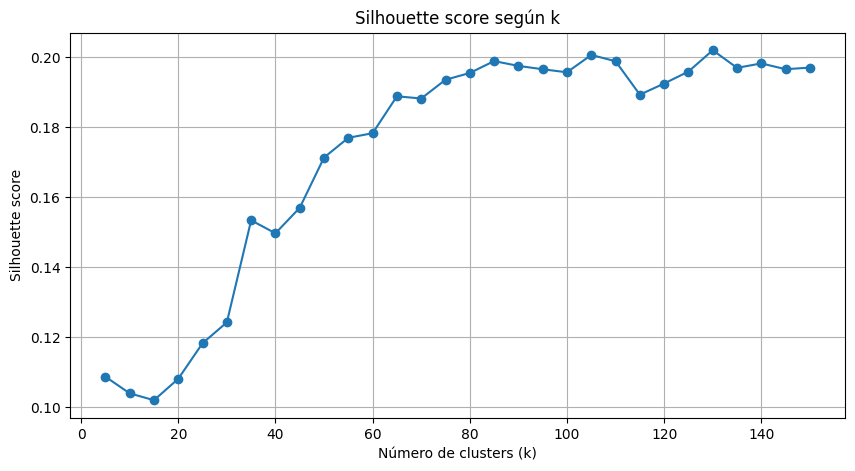

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score según k')
plt.grid(True)
plt.show()

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

In [15]:
k_values = range(5, 151, 5)
inertias = []
silhouette_scores_v2 = []  # recalculamos junto con inercia para tenerlo todo en un único bucle

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_train_pca)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inercia={kmeans.inertia_:.2f}")

k=5: inercia=17074.91
k=10: inercia=14760.67
k=15: inercia=13501.86
k=20: inercia=12438.46
k=25: inercia=11331.74
k=30: inercia=10486.67
k=35: inercia=9716.96
k=40: inercia=9142.75
k=45: inercia=8589.32
k=50: inercia=8013.91
k=55: inercia=7575.40
k=60: inercia=7113.36
k=65: inercia=6737.89
k=70: inercia=6412.48
k=75: inercia=6052.83
k=80: inercia=5784.68
k=85: inercia=5451.21
k=90: inercia=5212.12
k=95: inercia=4985.23
k=100: inercia=4738.54
k=105: inercia=4512.06
k=110: inercia=4260.26
k=115: inercia=4073.12
k=120: inercia=3869.55
k=125: inercia=3658.53
k=130: inercia=3431.16
k=135: inercia=3295.28
k=140: inercia=3095.32
k=145: inercia=2931.05
k=150: inercia=2769.72


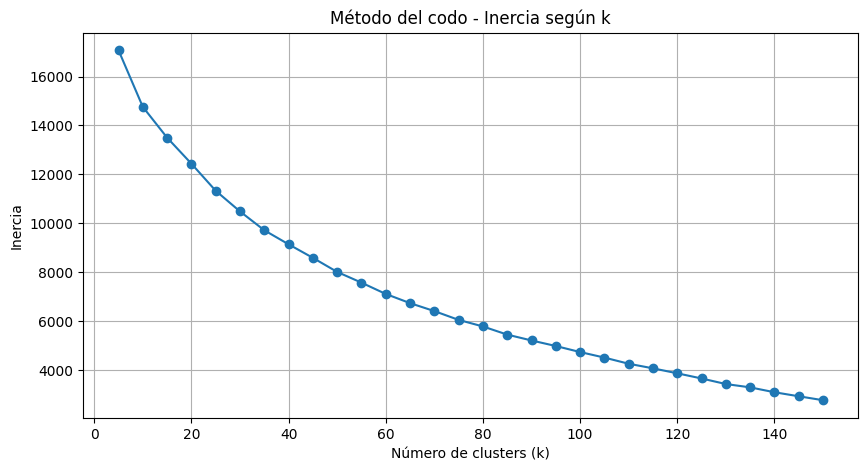

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo - Inercia según k')
plt.grid(True)
plt.show()

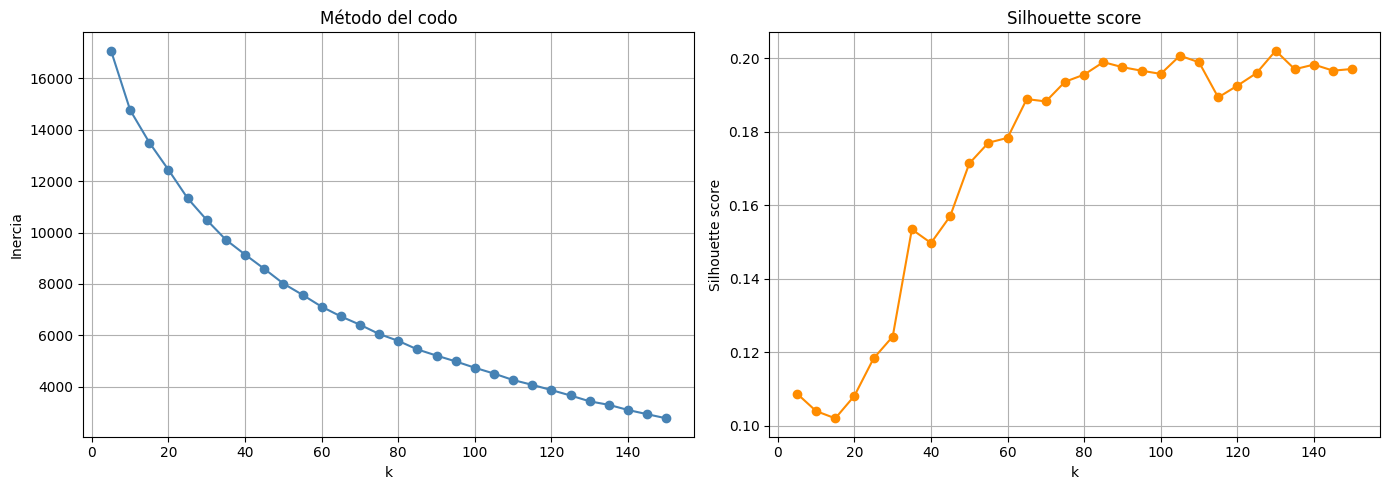

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(True)

axes[1].plot(list(k_values), silhouette_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Ambos métodos coincicen cerca del valor de 40 para k.

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [18]:
best_k = 40

best_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_model.fit(X_train_pca)

print(f"Mejor k (silhouette): {best_k}")
print(f"Inercia del modelo final: {best_model.inertia_:.2f}")
print(f"Silhouette score del modelo final: {silhouette_score(X_train_pca, best_model.labels_):.4f}")

Mejor k (silhouette): 40
Inercia del modelo final: 9142.75
Silhouette score del modelo final: 0.1497


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Cluster 0: 5 imágenes


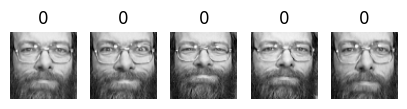

Cluster 1: 10 imágenes


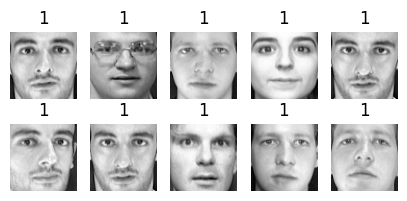

Cluster 2: 8 imágenes


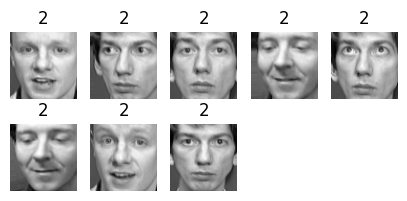

Cluster 3: 15 imágenes


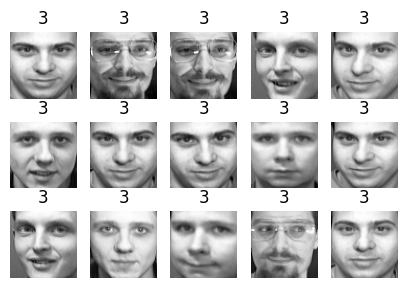

Cluster 4: 8 imágenes


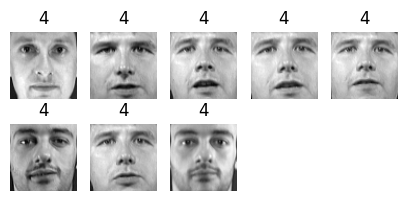

Cluster 5: 7 imágenes


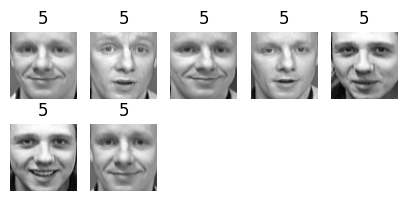

Cluster 6: 9 imágenes


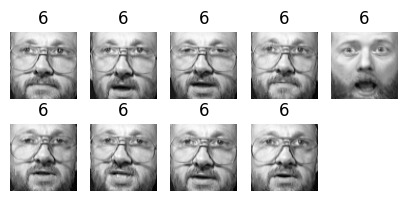

Cluster 7: 3 imágenes


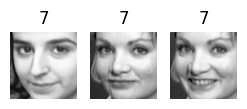

Cluster 8: 14 imágenes


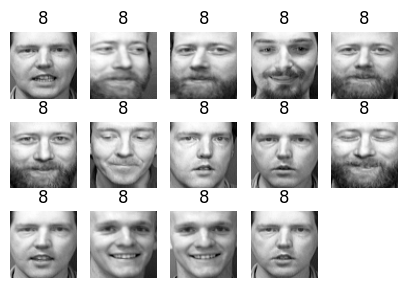

Cluster 9: 14 imágenes


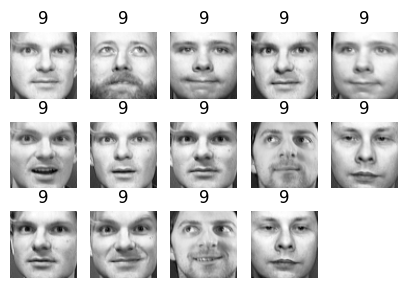

In [19]:
# Etiquetas asignadas por el modelo (una por cada imagen de train)
labels_clusters = best_model.labels_

# X_train tiene las features originales (píxeles), X_train_pca son las transformadas
# Para visualizar las caras necesitamos las features originales, no las PCA
X_train_array = X_train.values if hasattr(X_train, 'values') else X_train

for cluster_id in range(10):
    indices = np.where(labels_clusters == cluster_id)[0]
    
    if len(indices) == 0:
        print(f"Cluster {cluster_id}: sin imágenes asignadas")
        continue
    
    print(f"Cluster {cluster_id}: {len(indices)} imágenes")
    faces_cluster = X_train_array[indices]
    labels_cluster = [cluster_id] * len(indices)
    
    plot_faces(faces_cluster, labels_cluster)

Se pueden observar caras relativamente similares en todos los clústeres.

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_val_pred):.4f}")
print(classification_report(y_val, y_val_pred))

Accuracy en validación: 0.9750
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00       

c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [23]:
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape, X_val_pca.shape, X_test_pca.shape)

(320, 221) (40, 221) (40, 221)


In [24]:
# Transformar cada conjunto: las nuevas features son las distancias a los 40 centroides
X_train_reduced = best_model.transform(X_train_pca)
X_val_reduced = best_model.transform(X_val_pca)
X_test_reduced = best_model.transform(X_test_pca)

print(f"Shape original (tras PCA): {X_train_pca.shape}")
print(f"Shape reducido (tras KMeans): {X_train_reduced.shape}")

Shape original (tras PCA): (320, 221)
Shape reducido (tras KMeans): (320, 40)


In [25]:

#Reentrenamos random forest
clf_reduced = RandomForestClassifier(n_estimators=150, random_state=42)
clf_reduced.fit(X_train_reduced, y_train)

y_val_pred_reduced = clf_reduced.predict(X_val_reduced)

print(f"Accuracy en validación (KMeans reducido): {accuracy_score(y_val, y_val_pred_reduced):.4f}")
print(classification_report(y_val, y_val_pred_reduced))

Accuracy en validación (KMeans reducido): 0.8500
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       0.50      1.00      0.67         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       0.00      0.0

c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sandy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [26]:
print(f"Accuracy con features originales (4096 píxeles): {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Accuracy con features reducidas (40 distancias a centroides): {accuracy_score(y_val, y_val_pred_reduced):.4f}")

Accuracy con features originales (4096 píxeles): 0.9750
Accuracy con features reducidas (40 distancias a centroides): 0.8500


En esta comparativa queda registrado que se pierde información al comprimir cada imagen solo a 40 números. Sin embargo, el descenso en accuracy es muy pequeño a pesar de haber utilizado solo un pequeño porcentaje de las features (40 de 4096).

### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)